# BDAP LEA: il peso della prevenzione nelle ASL italiane (2024)

Prima lettura analitica per una discussion `Analisi`.

- **Obiettivo**: calcolare l'incidenza percentuale della Prevenzione Collettiva e Sanita' Pubblica sulla spesa corrente di ogni ASL nel consuntivo 2024.
- **Dati**: mart `mart_spesa_enti_2024` (BDAP LEA).
- **Orizzonte**: consuntivo 2024, livello ente ASL.
- **Riferimento**: soglia LEA del 5% come minimo indicato.
- **Nota**: il consuntivo 2024 e' l'ultimo anno completo disponibile.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

pd.options.display.float_format = '{:,.1f}'.format

def find_workspace_root(start: Path) -> Path:
    # Sale dalla posizione corrente finche' non trova dataset-incubator
    candidate = start.resolve()
    if candidate.is_file():
        candidate = candidate.parent
    for _ in range(15):
        if (candidate / 'dataset-incubator').exists():
            return candidate
        parent = candidate.parent
        if parent == candidate:
            break
        candidate = parent
    raise RuntimeError(f'Workspace root non trovato (partito da {start})')

WORKSPACE_ROOT = find_workspace_root(Path.cwd())
mart_path = WORKSPACE_ROOT / 'dataset-incubator' / 'out' / 'data' / 'mart' / 'bdap_lea' / '2024' / 'mart_spesa_enti_2024.parquet'

if not mart_path.exists():
    raise FileNotFoundError(f'Mart non trovato: {mart_path.resolve()}')

con = duckdb.connect()


### 1. Incidenza della prevenzione per ASL

Per ogni ASL, confrontiamo il totale della Prevenzione Collettiva e Sanita' Pubblica con la spesa corrente totale (TOTALE GENERALE).

In [2]:
query = """
WITH prevenzione AS (
    SELECT 
        descrizione_ente,
        round(sum(importo_totale), 0) as prev_totale
    FROM read_parquet(?)
    WHERE descrizione_voce_contabile = 'TOTALE PREVENZIONE COLLETTIVA E SANITA'' PUBBLICA'
    GROUP BY descrizione_ente
),
totale AS (
    SELECT 
        descrizione_ente,
        round(sum(importo_totale), 0) as spesa_corrente_totale
    FROM read_parquet(?)
    WHERE descrizione_voce_contabile = 'TOTALE GENERALE'
      AND descrizione_ente LIKE '%AZIENDA%'
    GROUP BY descrizione_ente
),
calcolo AS (
    SELECT 
        t.descrizione_ente,
        t.spesa_corrente_totale,
        coalesce(p.prev_totale, 0) as prev_totale,
        round(coalesce(p.prev_totale, 0) / t.spesa_corrente_totale * 100, 2) as pct_prev
    FROM totale t
    LEFT JOIN prevenzione p ON t.descrizione_ente = p.descrizione_ente
)
SELECT * FROM calcolo
ORDER BY pct_prev DESC
"""

df = con.execute(query, [str(mart_path), str(mart_path)]).df()


In [3]:
df[['descrizione_ente', 'spesa_corrente_totale', 'prev_totale', 'pct_prev']].head(10)


,descrizione_ente,spesa_corrente_totale,prev_totale,pct_prev
0,AZIENDA REGIONALE DELLA SALUTE REGIONE SARDEGN...,"52,980,007.0","7,630,904.0",14.4
1,AZIENDA SANITARIA LOCALE NAPOLI 1 CENTRO,"2,384,766,764.0","253,816,461.0",10.6
2,AZIENDA SANITARIA LOCALE NAPOLI 3 SUD,"2,024,029,614.0","201,918,082.0",10.0
3,AZIENDA SANITARIA PROVINCIALE DI VIBO VALENTIA,"345,490,420.0","33,338,134.0",9.7
4,AZIENDA SANITARIA PROVINCIALE DI CATANZARO,"786,419,415.0","70,939,376.0",9.0
5,AZIENDA SANITARIA LOCALE BENEVENTO,"578,828,353.0","51,404,794.0",8.9
6,AZIENDA SANITARIA PROVINCIALE DI SIRACUSA,"858,036,578.0","68,650,616.0",8.0
7,AZIENDA SANITARIA PROVINCIALE DI CALTANISSETTA,"636,164,605.0","45,945,169.0",7.2
8,AZIENDA SOCIO SANITARIA LOCALE N.7 DEL SULCIS,"305,437,343.0","19,541,397.0",6.4
9,AZIENDA UNITA' SANITARIA LOCALE ROMA 4,"693,628,598.0","44,247,091.0",6.4


### 2. Sintesi nazionale

Quante ASL superano la soglia del 5%?

In [4]:
summary = con.execute("""
SELECT 
    count(*) as totale_enti,
    count(*) FILTER (WHERE pct_prev >= 5) as enti_sopra_5,
    count(*) FILTER (WHERE pct_prev < 5) as enti_sotto_5,
    round(avg(pct_prev), 2) as pct_media,
    min(pct_prev) as pct_min,
    max(pct_prev) as pct_max,
    percentile_cont(0.5) WITHIN GROUP (ORDER BY pct_prev) as pct_mediana
FROM df
""").fetchdf()

summary


,totale_enti,enti_sopra_5,enti_sotto_5,pct_media,pct_min,pct_max,pct_mediana
0,183,30,153,3.0,0.0,14.4,3.2


### 3. Prime letture

- **Solo 30 ASL su 183 (16.4%)** superano la soglia del 5%.
- La **mediana e' al 3.18%**, ben sotto il riferimento LEA.
- La **media e' 3.04%**: le poche ASL sopra il 5% tirano su la media rispetto alla mediana.
- **153 ASL (83.6%)** stanno sotto il 5%.
- Il massimo e' 14.4% (ARES Sardegna), ma e' un ente regionale, non una ASL operativa standard.

**Conclusione**: la prevenzione collettiva e' marginalizzata nella spesa corrente della maggioranza delle ASL italiane. Il dato non e' solo territoriale: anche molte ASL del Nord sono sotto il 5%.

### 4. Grafico - distribuzione percentuale

Istogramma della percentuale di prevenzione per ASL, con la soglia LEA al 5% evidenziata.

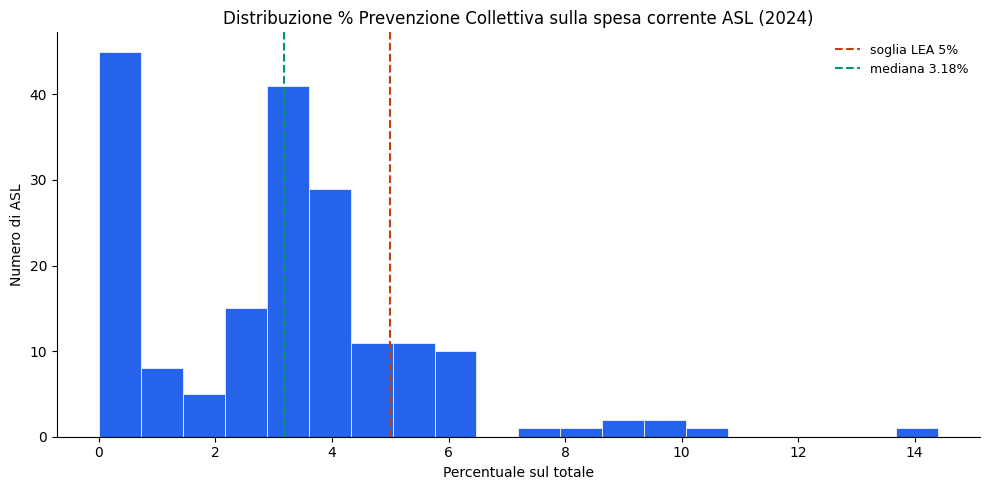

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['pct_prev'], bins=20, color='#2563eb', edgecolor='white', linewidth=0.5)
ax.axvline(x=5, color='#c2410c', linestyle='--', linewidth=1.5, label='soglia LEA 5%')
ax.axvline(x=df['pct_prev'].median(), color='#059669', linestyle='--', linewidth=1.5, label=f"mediana {df['pct_prev'].median():.2f}%")

ax.set_title('Distribuzione % Prevenzione Collettiva sulla spesa corrente ASL (2024)')
ax.set_xlabel('Percentuale sul totale')
ax.set_ylabel('Numero di ASL')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

figures_dir = Path.cwd() / '..' / '..' / 'preview'
figures_dir.mkdir(parents=True, exist_ok=True)
out = figures_dir / 'bdap_lea_prevenzione_pct_distribuzione.png'
plt.savefig(out, dpi=150)
plt.show()


### 5. Top 10 e Bottom 10

Le ASL con la quota piu' alta e piu' bassa di prevenzione.

In [6]:
top10 = df.nlargest(10, 'pct_prev')[['descrizione_ente', 'pct_prev']]
bottom10 = df.nsmallest(10, 'pct_prev')[['descrizione_ente', 'pct_prev']]

print('Top 10 ASL per % prevenzione')
display(top10)
print()
print('Bottom 10 ASL per % prevenzione')
display(bottom10)


Top 10 ASL per % prevenzione


,descrizione_ente,pct_prev
0,AZIENDA REGIONALE DELLA SALUTE REGIONE SARDEGN...,14.4
1,AZIENDA SANITARIA LOCALE NAPOLI 1 CENTRO,10.6
2,AZIENDA SANITARIA LOCALE NAPOLI 3 SUD,10.0
3,AZIENDA SANITARIA PROVINCIALE DI VIBO VALENTIA,9.7
4,AZIENDA SANITARIA PROVINCIALE DI CATANZARO,9.0
5,AZIENDA SANITARIA LOCALE BENEVENTO,8.9
6,AZIENDA SANITARIA PROVINCIALE DI SIRACUSA,8.0
7,AZIENDA SANITARIA PROVINCIALE DI CALTANISSETTA,7.2
8,AZIENDA SOCIO SANITARIA LOCALE N.7 DEL SULCIS,6.4
9,AZIENDA UNITA' SANITARIA LOCALE ROMA 4,6.4



Bottom 10 ASL per % prevenzione


,descrizione_ente,pct_prev
153,AZIENDA OSPEDALIERA COMPLESSO OSPEDALIERO SAN ...,0.0
154,AZIENDA OSPEDALIERA UNIVERSITARIA POLICLINICO ...,0.0
155,AZIENDA OSPEDALIERA UNIVERSITARIA FEDERICO II,0.0
156,AZIENDA REGIONALE EMERGENZA SANITARIA - ARES 118,0.0
157,AZIENDA OSPEDALIERA DI RILIEVO NAZIONALE E DI ...,0.0
158,AZIENDA OSPEDALIERA PER L'EMERGENZA CANNIZZARO...,0.0
159,AZIENDA OSPEDALIERO UNIVERSITARIA POLICLINICO ...,0.0
160,AZIENDA OSPEDALIERO-UNIVERSITARIA S. ANDREA,0.0
161,AZIENDA SANITARIA ZERO DELLA REGIONE PIEMONTE,0.0
162,AZIENDA OSPEDALIERO-UNIVERSITARIA RENATO DULBECCO,0.0


### 6. Caveat

- **Consuntivo 2024**: ultimo anno completo, ma alcuni enti potrebbero avere dati parziali o non ancora consolidati.
- **Perimetro LEA**: la voce "Prevenzione Collettiva e Sanita' Pubblica" e' un aggregato contabile. Non include attivita' di prevenzione svolte in altri capitoli (es. screening integrati nell'assistenza distrettuale).
- **Soglia 5%**: e' un riferimento minimo previsto dai LEA, non un obiettivo vincolante o una misura di efficacia.
- **Enti atipici**: ARES Sardegna e enti regionali hanno strutture diverse dalle ASL operative - i loro valori non sono direttamente comparabili.
- **Nessuna correzione pro-capite**: qui si guarda la quota percentuale, non la spesa per abitante. Un'ASL piccola puo' avere una quota alta ma un volume assoluto basso.